# CV Summarization Evaluation
This notebook loads a Word CV, summarizes it using your local summarize_cv.py, and generates evaluation charts.

In [5]:
%pip install python-docx pypdf

# Đọc DOCX
from docx import Document

# Đọc PDF
from pypdf import PdfReader

# Vẽ biểu đồ
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán
import numpy as np
import pandas as pd

# Import model đã train
from summarize_cv import summarize_resume_multilang, tfidf_en, tfidf_vi


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
def read_docx(path):
    doc = Document(path)
    text = "\n".join([p.text for p in doc.paragraphs])
    return text

def read_pdf(path):
    reader = PdfReader(path)
    text = ""
    for page in reader.pages:
        text += page.extract_text()
    return text

def load_cv(path):
    if path.lower().endswith(".docx"):
        return read_docx(path)
    elif path.lower().endswith(".pdf"):
        return read_pdf(path)
    else:
        raise Exception("Unsupported file format")


In [7]:
cv_path = "Quyet-Truong-TopCV.vn-221125.51508.pdf"

text = load_cv(cv_path)

print("Preview CV:")
print(text[:600])


invalid pdf header: b'\n%PDF'


Preview CV:
Quyet Truong
Lậ p trình viên
 0123456789
 quyetlun822004@gmail.com
 qu ậ n 9
 24/08/1997
 Nam
Mụ c tiêu ngh ề  nghi ệ p
V ớ i 6 n ă m trong ngh ề  l ậ p trình,
tri ể n khai tr ự c ti ế p h ơ n 30 d ự  án,
tôi mong mu ố n ứ ng tuy ể n vào v ị  trí
Senior c ủ a Công ty đ ể  có th ể  áp
d ụ ng nh ữ ng ki ế n th ứ c, kinh nghi ệ m
l ậ p trình c ủ a b ả n thân đ ể  nâng c ấ p
s ả n ph ẩ m và mang l ạ i nh ữ ng giá tr ị
h ữ u ích cho doanh nghi ệ p. Đ ồ ng
th ờ i, m ụ c tiêu phát tri ể n trong vòng
2 n ă m t ớ i c ủ a tôi s ẽ  tr ở  thành m ộ t
Lead gi ỏ i.
Kỹ  n ă ng
K ỹ  n ă ng giao ti ế p
K 


In [8]:
summary, lang = summarize_resume_multilang(text, tfidf_en, tfidf_vi)

len_orig = len(text.split())
len_sum = len(summary.split())
ratio = round(len_sum / len_orig, 4) if len_orig > 0 else 0

print("Original length:", len_orig)
print("Summary length:", len_sum)
print("Compression ratio:", ratio)

print("\n--- SUMMARY ---\n")
print(summary)


Original length: 1281
Summary length: 504
Compression ratio: 0.3934

--- SUMMARY ---

Kỹ n ă ng K ỹ n ă ng giao ti ế p K ỹ n ă ng đ àm phán K ỹ n ă ng thuy ế t trình Sở thích ● Đ ọ c sách ● N ấ u ă n  Họ c v ấ n Công ngh ệ thông tin 2014 - 2017 Đ ạ i h ọ c TopCV •T ố t nghi ệ p lo ạ i Gi ỏ i •Đ ạ t h ọ c b ổ ng 2016 và 2017 •Đ ạ t gi ả i nhì nghiên c ứ u khoa h ọ c công ngh ệ  Kinh nghi ệ m làm vi ệ c Front End Developer 2021 - 2024 Công ty TNHH MTV SVT •Qu ả n lý các d ự án phát tri ể n trang web t ừ thi ế t k ế ban đ ầ u cho đ ế n hoàn thi ệ n, t ố i ư u m ọ i kh ả n ă ng t ươ ng thích trên nhi ề u trình duy ệ t và n ề n t ả ng. •Tham gia đ ánh giá và th ử nghi ệ m các tính n ă ng m ớ i đ ể đ ả m b ả o web t ươ ng thích v ớ i các tính n ă ng hi ệ n có. •Ti ế n hành đ ào t ạ o cho khách hàng v ề cách x ử lý h ệ th ố ng qu ả n lý n ộ i dung trang web. •Nghiên c ứ u, phát tri ể n công ngh ệ m ớ i đ ể ứ ng d ụ ng xây d ự ng các s ả n ph ẩ m d ị ch v ụ m ớ i •H ỗ tr ợ các thành viên tro

In [9]:
# Tách câu thủ công (tự viết ở evaluate)
sentences = [s.strip() for s in text.split(".") if len(s.strip()) > 0]

# Nếu CV quá ngắn → bỏ
if len(sentences) < 2:
    print("CV quá ngắn, không thể vẽ biểu đồ similarity.")
else:
    from summarize_cv import clean_text, build_similarity_matrix, get_tfidf_by_lang

    cleaned_sents = [clean_text(s) for s in sentences]
    tfidf_vec = get_tfidf_by_lang(lang, tfidf_en, tfidf_vi)
    sim_matrix = build_similarity_matrix(cleaned_sents, tfidf_vec)


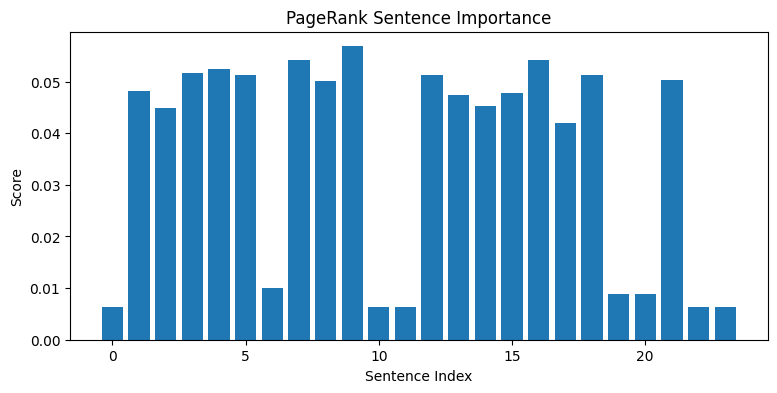

In [10]:
from summarize_cv import pagerank

if len(sentences) >= 2:
    scores = pagerank(sim_matrix)

    plt.figure(figsize=(9,4))
    plt.bar(range(len(scores)), scores)
    plt.title("PageRank Sentence Importance")
    plt.xlabel("Sentence Index")
    plt.ylabel("Score")
    plt.show()


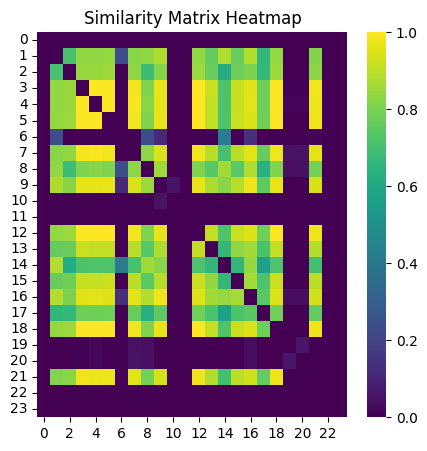

In [11]:
if len(sentences) >= 2:
    plt.figure(figsize=(5,5))
    sns.heatmap(sim_matrix, cmap="viridis", annot=False)
    plt.title("Similarity Matrix Heatmap")
    plt.show()
